In [1]:
building = 3
hours = 24
price = 'Realistic'
load_forecast = 0

lat = 52.090
long = 5.088

timings = {}

# Setup

In [2]:
import torch
import pandas as pd
import numpy as np
import time
import os

from sklearn.metrics import mean_squared_error as mse
import matplotlib.pyplot as plt

import src.data.dataprep as prep
import src.data.featurisation as features

from src.models.lstm import LSTM
from src.models.lstmopt import LSTMOPT
from src.models.lstmopt import CVXLayer

from src.training.training import  Training as Training
from src.training.training_opt import Training as Training_opt

import src.optimization.pv_battery as pvb

import src.tensors.tensorisation as tensor
import src.util.open_meteo_api as meteo

def torch_py(torch_tensor):
    return torch_tensor.cpu().detach().numpy().flatten()

def rescale(values, scaler):
    rescaled_values = values * (scaler[1] - scaler[0]) + scaler[0]   
    return rescaled_values

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Import the base data and resample it from 5 minutes to hourly
nl_data = prep.dutch_data('../data/Dutchdata_clean/building_' + str(building) + '.parquet', 'h', price=price)
featurisation = features.Featurisation(nl_data)
nl_data = featurisation.cyclic_features(yearly=False)[0]

In [4]:
if load_forecast == 0:
    nl_data['load_fcst'] = nl_data['load']
else:
    load_fcst_data = pd.read_csv('../data/load_fcsts/building_' + str(building) + '_' + str(load_forecast) + '_noise_forecast.csv', index_col=0)
    nl_data['load_fcst'] = load_fcst_data['load'].values

In [5]:
weather = meteo.Open_meteo(lat, long, nl_data.index[0].strftime('%Y-%m-%d'), nl_data.index[-1].strftime('%Y-%m-%d'))
weather_data = weather.get_open_meteo_hourly()
weather_data.index = weather_data['date']
weather_data.index = weather_data.index.tz_localize(None)

Coordinates 52.056236267089844°N 5.128676414489746°E
Elevation 0.0 m asl
Timezone None None
Timezone difference to GMT+0 0 s


In [6]:
nl_data['direct_rad'] = meteo.simulate_forecast(weather_data['direct_radiation'], noise_scale=0.5, skewness=-1.5, smooth_param=7)

In [7]:
mse(weather_data['direct_radiation'], nl_data['direct_rad'], squared=False) / (max(weather_data['direct_radiation']) - min(weather_data['direct_radiation']))

0.10443716541223354

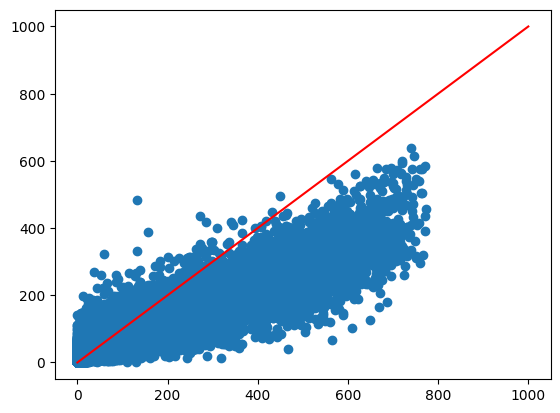

In [8]:
x = np.linspace(0,1000, 10000)
y = x
plt.scatter(weather_data['direct_radiation'], nl_data['direct_rad'])
plt.plot(x,y, c='r')

In [10]:
nl_data['load'].resample('Y').sum()

2018-12-31    1807.255567
2019-12-31    4089.795600
2020-12-31    4185.071846
2021-12-31    1886.871000
Freq: A-DEC, Name: load, dtype: float64

In [11]:
battery_capacity = round(nl_data['load'].resample('Y').sum().max() * 1.1 / 1000,1)

In [12]:
battery_capacity

4.6

# Parameters

In [14]:
# Base parameters
max_charge = battery_capacity/2.7
max_discharge = max_charge
epochs = 150
layers = 3
neurons = 200
train_test_split = 0.6

past_features = ['solar_energy']
future_features = ['direct_rad', 'hour_sin','hour_cos']
opt_features = ['load', 'load_fcst','offtake','injection']

opt_future_features = future_features + opt_features
features = len(past_features) + len(future_features)
# Create domain_min and domain_max
domain_min = [None] * len(past_features) + [None] * len(future_features)
domain_max = [None] * len(past_features) + [None] * len(future_features)
remaining_opt_features = len(opt_future_features) - len(future_features)
domain_min += [0] * remaining_opt_features + [None]
domain_max += [1] * remaining_opt_features + [None]

In [15]:
pvb_system = pvb.PV_battery(nl_data, building, battery_capacity, max_charge, max_discharge, self_consumption=False)

# Previous problems

We first need the initial battery states for the hour prior to the current optimization as input for our current optimization. This requires looping over all previous timeslots, as every consecutive optimization needs the initial battery state coming from the previous one.

In [16]:
# We evaluate how many times we need to loop over the optimization
problems = 24 - hours

In [17]:
# We keep the train initial batteries in this list
initial_battery_train_cvx = []
initial_battery_train_lstm_cvx = []

# We keep the test initial batteries in this list
initial_battery_test_cvx = []
initial_battery_test_lstm_cvx = []

# These values get updated each loop
old_T = 24          # The first timeslot under consideration: 24 hours to optimize 
lags = 24           # The number of lags for this first timeslot: the 24 previous hours
forecast_gap = 0    # The gap after every forecast which is 0 when we need to forecast 24 hours

# loop over each of the problems
for i in range(problems):
       
    print('Setting up optimization for hour ' + str(i))
    
    # Get the optimization problem for the current problem
    problem, variables, parameters = pvb_system.create_optimization_problem(old_T)
    
    # Get what actually happens based on the (dis)charging scheme to obtain the initial battery value for the next hour
    problem_post, variables_post, parameters_post = pvb_system.create_post_forecast_optimization_problem(old_T)

    # Tensors for training a base forecaster
    domain_min_perfect = [None, None, None, 0]
    domain_max_perfect = [None, None, None, 1]
    tensors = tensor.Tensors(pvb_system.house,'solar_energy',past_features,future_features,lags,old_T, forecast_gap=forecast_gap,train_test_split=train_test_split, domain_min=domain_min_perfect,domain_max=domain_max_perfect)
    _, _, y_train, y_test, scalers = tensors.create_tensor()

    # Tensors for training an E2E network
    tensors_cvx = tensor.Tensors(pvb_system.house,'solar_energy',past_features,opt_future_features,lags,old_T, forecast_gap=forecast_gap, train_test_split=train_test_split, domain_min=domain_min, domain_max=domain_max)

    # We don't need the Y values as they are identical to the ones from the base forecaster
    X_train_cvx, X_test_cvx, _, _, scalers_cvx = tensors_cvx.create_tensor()
    X_train_lstm_cvx, X_test_lstm_cvx, _, _, scalers_lstm_cvx = tensors_cvx.create_tensor()

    # We have to assign initial battery values to the current optimization at hand, first we create an empty tensor
    initial_bat_tensor_train_cvx = torch.zeros([X_train_cvx.shape[0],lags,1])
    initial_bat_tensor_test_cvx = torch.zeros([X_test_cvx.shape[0],lags,1])

    initial_bat_tensor_train_lstm_cvx = torch.zeros([X_train_lstm_cvx.shape[0],lags,1])
    initial_bat_tensor_test_lstm_cvx = torch.zeros([X_test_lstm_cvx.shape[0],lags,1])

    # If this is the first optimization done at midnight, the initial battery is set at 50% of the capacity, as we also make sure that the end
    # state of the battery from the previous day is 50%
    if i == 0:       
        initial_bat_tensor_train_cvx[:,-1,:] = battery_capacity * 0.5
        initial_bat_tensor_test_cvx[:,-1,:] = battery_capacity * 0.5

        initial_bat_tensor_train_lstm_cvx[:,-1,:] = battery_capacity * 0.5
        initial_bat_tensor_test_lstm_cvx[:,-1,:] = battery_capacity * 0.5


    # If it is not the first optimization, we obtain the initial battery values from the list of battery values we have been maintaining 
    else:
        initial_bat_tensor_train_cvx[:,-1,:] = torch.tensor(initial_battery_train_cvx[i-1]).unsqueeze(-1)
        initial_bat_tensor_test_cvx[:,-1,:] = torch.tensor(initial_battery_test_cvx[i-1]).unsqueeze(-1) 

        initial_bat_tensor_train_lstm_cvx[:,-1,:] = torch.tensor(initial_battery_train_lstm_cvx[i-1]).unsqueeze(-1)
        initial_bat_tensor_test_lstm_cvx[:,-1,:] = torch.tensor(initial_battery_test_lstm_cvx[i-1]).unsqueeze(-1)

    # We add this tensor to our X tensors for the E2E network
    X_train_cvx = torch.concat([X_train_cvx, initial_bat_tensor_train_cvx],dim=-1)
    X_test_cvx = torch.concat([X_test_cvx, initial_bat_tensor_test_cvx],dim=-1)

    X_train_lstm_cvx = torch.concat([X_train_lstm_cvx, initial_bat_tensor_train_lstm_cvx],dim=-1)
    X_test_lstm_cvx = torch.concat([X_test_lstm_cvx, initial_bat_tensor_test_lstm_cvx],dim=-1)

    # Create the models for PV forecasts
    cvx = LSTMOPT(features,neurons,layers,old_T,0.5,problem,parameters,variables,scalers_cvx[0]).to(device)
    lstm_cvx = LSTMOPT(features,neurons,layers,old_T,0.5,problem,parameters,variables,scalers_lstm_cvx[0]).to(device)

    cvx.load_state_dict(torch.load('../models/CVX/building' + str(building) + '_' + str(old_T) + 'h_' + str(battery_capacity) + 'kwh_' + str(load_forecast) + 'noise.pth'))
    lstm_cvx.load_state_dict(torch.load('../models/LSTM_CVX/building' + str(building) + '_' + str(old_T) + 'h_' + str(battery_capacity) + 'kwh_' + str(load_forecast) + 'noise.pth'))

    print('Forecasting PV')
    
    # Forecast the PV
    pv_cvx_train, _ = cvx(X_train_cvx[:,:,0:features].to(device),
                         X_train_cvx[:,-old_T:,-4].to(device),
                         X_train_cvx[:,-old_T:,-3].to(device),
                         X_train_cvx[:,-old_T:,-2].to(device),
                         X_train_cvx[:,-1,-1].to(device))
    
    pv_cvx_test, _ = cvx(X_test_cvx[:,:,0:features].to(device),
                         X_test_cvx[:,-old_T:,-4].to(device),
                         X_test_cvx[:,-old_T:,-3].to(device),
                         X_test_cvx[:,-old_T:,-2].to(device),
                         X_test_cvx[:,-1,-1].to(device))

    pv_lstm_cvx_train, _ = lstm_cvx(X_train_lstm_cvx[:,:,0:features].to(device),
                                    X_train_lstm_cvx[:,-old_T:,-4].to(device),
                                    X_train_lstm_cvx[:,-old_T:,-3].to(device),
                                    X_train_lstm_cvx[:,-old_T:,-2].to(device),
                                    X_train_lstm_cvx[:,-1,-1].to(device))

    pv_lstm_cvx_test, _ = lstm_cvx(X_test_lstm_cvx[:,:,0:features].to(device),
                                   X_test_lstm_cvx[:,-old_T:,-4].to(device),
                                   X_test_lstm_cvx[:,-old_T:,-3].to(device),
                                   X_test_lstm_cvx[:,-old_T:,-2].to(device),
                                   X_test_lstm_cvx[:,-1,-1].to(device))


    # Make a list for the initial energy of the current timeslot for each day in the train and test sets
    cvx_train_initial_energy_t = []
    lstm_cvx_train_initial_energy_t = []

    cvx_test_initial_energy_t = []
    lstm_cvx_test_initial_energy_t = []

    print('Obtaining initial energy parameters for hour ' + str(i+1))
    
    # Loop over every day, first use the forecast of PV, next plug in the real PV and the charge and discharge schedules to obtain the real battery state
    for j in range(len(X_train_cvx)):
        # CVX forecast
        parameters[0].value = torch_py(rescale(pv_cvx_train[j], scalers_cvx[0]))
        parameters[1].value = torch_py(X_train_cvx[j,-old_T:,-4])
        parameters[2].value = torch_py(X_train_cvx[j,-old_T:,-3])
        parameters[3].value = torch_py(X_train_cvx[j,-old_T:,-2])
        parameters[4].value = round(torch_py(X_train_cvx[j,-1:,-1].double())[0],4)
        problem.solve()
    
        # CVX real
        parameters_post[0].value = torch_py(y_train[j,:])
        parameters_post[1].value = torch_py(X_train_cvx[j,-old_T:,-5]) # CHANGED from 4 to 5: we use the REAL load to find out what our energy situation will actually be
        parameters_post[2].value = torch_py(X_train_cvx[j,-old_T:,-3])
        parameters_post[3].value = torch_py(X_train_cvx[j,-old_T:,-2])
        parameters_post[4].value = round(torch_py(X_train_cvx[j,-1:,-1].double())[0],4)
        parameters_post[5].value = variables[-2].value
        parameters_post[6].value = variables[-1].value
        problem_post.solve()
        cvx_train_initial_energy_t.append(variables_post[-1].value[1])

        # LSTM-CVX forecast
        parameters[0].value = torch_py(rescale(pv_lstm_cvx_train[j], scalers_cvx[0]))
        parameters[1].value = torch_py(X_train_lstm_cvx[j,-old_T:,-4])
        parameters[2].value = torch_py(X_train_lstm_cvx[j,-old_T:,-3])
        parameters[3].value = torch_py(X_train_lstm_cvx[j,-old_T:,-2])
        parameters[4].value = round(torch_py(X_train_lstm_cvx[j,-1:,-1].double())[0],4)
        problem.solve()

        # LSTM-CVX real
        parameters_post[0].value = torch_py(y_train[j,:])
        parameters_post[1].value = torch_py(X_train_lstm_cvx[j,-old_T:,-5]) # CHANGED from 4 to 5: we use the REAL load to find out what our energy situation will actually be
        parameters_post[2].value = torch_py(X_train_lstm_cvx[j,-old_T:,-3])
        parameters_post[3].value = torch_py(X_train_lstm_cvx[j,-old_T:,-2])
        parameters_post[4].value = round(torch_py(X_train_lstm_cvx[j,-1:,-1].double())[0],4)
        parameters_post[5].value = variables[-2].value
        parameters_post[6].value = variables[-1].value
        problem_post.solve()
        lstm_cvx_train_initial_energy_t.append(variables_post[-1].value[1])


    # Do the same for the test set
    for j in range(len(X_test_cvx)):
        # CVX forecast
        parameters[0].value = torch_py(rescale(pv_cvx_test[j], scalers_cvx[0]))
        parameters[1].value = torch_py(X_test_cvx[j,-old_T:,-4])
        parameters[2].value = torch_py(X_test_cvx[j,-old_T:,-3])
        parameters[3].value = torch_py(X_test_cvx[j,-old_T:,-2])
        parameters[4].value = round(torch_py(X_test_cvx[j,-1:,-1].double())[0],4)
        problem.solve()
    
        # CVX real
        parameters_post[0].value = torch_py(y_test[j,:])
        parameters_post[1].value = torch_py(X_test_cvx[j,-old_T:,-5]) # CHANGED from 4 to 5: we use the REAL load to find out what our energy situation will actually be
        parameters_post[2].value = torch_py(X_test_cvx[j,-old_T:,-3])
        parameters_post[3].value = torch_py(X_test_cvx[j,-old_T:,-2])
        parameters_post[4].value = round(torch_py(X_test_cvx[j,-1:,-1].double())[0],4)
        parameters_post[5].value = variables[-2].value
        parameters_post[6].value = variables[-1].value
        problem_post.solve()
        cvx_test_initial_energy_t.append(variables_post[-1].value[1])

        # LSTM-CVX forecast
        parameters[0].value = torch_py(rescale(pv_lstm_cvx_test[j], scalers_cvx[0]))
        parameters[1].value = torch_py(X_test_lstm_cvx[j,-old_T:,-4])
        parameters[2].value = torch_py(X_test_lstm_cvx[j,-old_T:,-3])
        parameters[3].value = torch_py(X_test_lstm_cvx[j,-old_T:,-2])
        parameters[4].value = round(torch_py(X_test_lstm_cvx[j,-1:,-1].double())[0],4)
        problem.solve()

        # LSTM-CVX real
        parameters_post[0].value = torch_py(y_test[j,:])
        parameters_post[1].value = torch_py(X_test_lstm_cvx[j,-old_T:,-5]) # CHANGED from 4 to 5: we use the REAL load to find out what our energy situation will actually be
        parameters_post[2].value = torch_py(X_test_lstm_cvx[j,-old_T:,-3])
        parameters_post[3].value = torch_py(X_test_lstm_cvx[j,-old_T:,-2])
        parameters_post[4].value = round(torch_py(X_test_lstm_cvx[j,-1:,-1].double())[0],4)
        parameters_post[5].value = variables[-2].value
        parameters_post[6].value = variables[-1].value
        problem_post.solve()
        lstm_cvx_test_initial_energy_t.append(variables_post[-1].value[1])


    # Add the initial battery values to our list
    initial_battery_train_cvx.append(cvx_train_initial_energy_t)
    initial_battery_test_cvx.append(cvx_test_initial_energy_t)

    initial_battery_train_lstm_cvx.append(lstm_cvx_train_initial_energy_t)
    initial_battery_test_lstm_cvx.append(lstm_cvx_test_initial_energy_t)

    old_T += -1         # Update the timeslots we have to forecast, 1 less than the previous optimization
    lags += 1           # Update the lags we can use for the forecast, we still use the full previous day, but have 1 more hour of the current day as well
    forecast_gap += 1   # Add to the gap between forecasts (f.e. the gap is 1 if we only have to forecast 23 hours)

# LSTM model

First we make forecasts in a 2-step approach, for which we do not need the optimization.

## Tensors

In [18]:
# Tensors for training
nl_tensors = tensor.Tensors(pvb_system.house,'solar_energy',past_features,future_features,lags,hours,forecast_gap=forecast_gap,train_test_split=train_test_split)
X_train_base, X_test_base, y_train_base, y_test_base, scalers = nl_tensors.create_tensor()

## Model

In [19]:
lstm = LSTM(features,neurons,layers,hours,0.5).to(device)

Step 0: Average train loss: 0.0556 | Average test loss: 0.0431
Step 5: Average train loss: 0.0111 | Average test loss: 0.0114
Step 10: Average train loss: 0.0080 | Average test loss: 0.0093
Step 15: Average train loss: 0.0088 | Average test loss: 0.0099
Step 20: Average train loss: 0.0076 | Average test loss: 0.0089
Step 25: Average train loss: 0.0071 | Average test loss: 0.0087
Step 30: Average train loss: 0.0076 | Average test loss: 0.0089
Step 35: Average train loss: 0.0073 | Average test loss: 0.0091
Step 40: Average train loss: 0.0070 | Average test loss: 0.0088
Step 45: Average train loss: 0.0084 | Average test loss: 0.0123
Step 50: Average train loss: 0.0082 | Average test loss: 0.0105
Step 55: Average train loss: 0.0071 | Average test loss: 0.0091
Step 60: Average train loss: 0.0073 | Average test loss: 0.0094
Step 65: Average train loss: 0.0071 | Average test loss: 0.0091
Step 70: Average train loss: 0.0071 | Average test loss: 0.0090
Step 75: Average train loss: 0.0067 | Aver

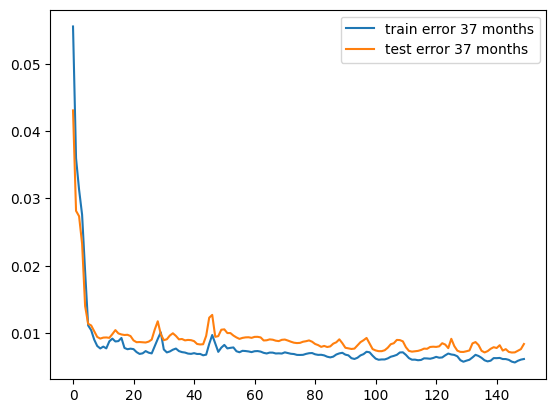

In [20]:
file_path = f"../models/LSTM_Weather/building{building}_{hours}h.pth"

if os.path.exists(file_path):
    lstm.load_state_dict(torch.load('../models/LSTM/building' + str(building) + '_' + str(hours) + 'h.pth'))
else:
    trainer_base = Training(lstm, X_train_base, y_train_base, X_test_base, y_test_base, epochs, learning_rate=0.0005)
    state_dicts_lstm, best_lstm = trainer_base.fit(verbose=2)

In [23]:
fcsts = lstm(X_test_base.to(device))

In [24]:
mse(torch_py(y_test_base), torch_py(fcsts), squared=False)

0.089870974

In [25]:
if not os.path.exists(file_path):
    lstm.load_state_dict(state_dicts_lstm[best_lstm])

# LSTM-CVX model

Next we make a model which integrates the optimization and the forecast. For this we need all parameters to do the optimization.

In [26]:
# Create the current optimization problem
problem, variables, parameters = pvb_system.create_optimization_problem(hours)
# Create the post-forecast optimization problem which we need to calculate the regret
problem_post, variables_post, parameters_post = pvb_system.create_post_forecast_optimization_problem(hours)

# Create CVX layers (or just use a cvxpy solver, the result should be the same)
cvx_real = CVXLayer(problem, parameters, variables)
cvx_post = CVXLayer(problem_post, parameters_post, variables_post)

## Tensors

We create tensors for the CVX neural network. We can use the data in our dataframe for this but we need 2 additional steps as well:
1. We need the initial battery states from the previous timestep
2. We need the daily cost of optimizing under a perfect forecast to train the neural network on the 'regret', the difference in costs using perfect knowledge and using a forecast

### Baseline tensors

In [27]:
# Tensors for training
nl_opt_tensors = tensor.Tensors(pvb_system.house,'solar_energy',past_features,opt_future_features,lags,hours,forecast_gap=forecast_gap, train_test_split=train_test_split, domain_min=domain_min, domain_max=domain_max)
X_train, X_test, _, _, scalers_opt = nl_opt_tensors.create_tensor()

### Initial battery states

Now we use the initial battery states which we obtained earlier from running the previous optimization programs

In [28]:
# Create an empty tensor to add to the X tensors
initial_bat_tensor_cvx_train = torch.zeros([X_train.shape[0],lags,1])
initial_bat_tensor_cvx_test = torch.zeros([X_test.shape[0],lags,1])

initial_bat_tensor_lstm_cvx_train = torch.zeros([X_train.shape[0],lags,1])
initial_bat_tensor_lstm_cvx_test = torch.zeros([X_test.shape[0],lags,1])


# If this is the first optimization done at midnight, the initial battery is set at 50% of the capacity, as we also make sure that the end
# state of the battery from the previous day is 50%
if problems == 0:
    initial_bat_tensor_cvx_train[:,-1,:] = battery_capacity * 0.5
    initial_bat_tensor_cvx_test[:,-1,:] = battery_capacity * 0.5

    initial_bat_tensor_lstm_cvx_train[:,-1,:] = battery_capacity * 0.5
    initial_bat_tensor_lstm_cvx_test[:,-1,:] = battery_capacity * 0.5


# If it is not the first optimization, we obtain the initial battery values from the list of battery values we have been maintaining 
else:
    initial_bat_tensor_cvx_train[:,-1,:] = torch.tensor(initial_battery_train_cvx[-1]).unsqueeze(-1)
    initial_bat_tensor_cvx_test[:,-1,:] = torch.tensor(initial_battery_test_cvx[-1]).unsqueeze(-1)

    initial_bat_tensor_lstm_cvx_train[:,-1,:] = torch.tensor(initial_battery_train_lstm_cvx[-1]).unsqueeze(-1)
    initial_bat_tensor_lstm_cvx_test[:,-1,:] = torch.tensor(initial_battery_test_lstm_cvx[-1]).unsqueeze(-1)

X_train_cvx = torch.concat([X_train, initial_bat_tensor_cvx_train],dim=-1)
X_test_cvx = torch.concat([X_test, initial_bat_tensor_cvx_test],dim=-1)

X_train_lstm_cvx = torch.concat([X_train, initial_bat_tensor_lstm_cvx_train],dim=-1)
X_test_lstm_cvx = torch.concat([X_test, initial_bat_tensor_lstm_cvx_test],dim=-1)

### Regret

Now we need to have optimal solutions given correct PV values in order to obtain the "regret" for training the E2E forecaster

1. We solve the optimization

In [29]:
# get the optimal parameters for the train set
cvx_vars_train = cvx_real(rescale(y_train_base,scalers[-1]),
                          X_train_cvx[:,-hours:,-5], # CHANGED from 4 to 5: we use the REAL load to get the optimal parameters (TBD!!!)
                          X_train_cvx[:,-hours:,-3],
                          X_train_cvx[:,-hours:,-2],
                          X_train_cvx[:,-1,-1])

lstm_cvx_vars_train = cvx_real(rescale(y_train_base,scalers[-1]),
                          X_train_lstm_cvx[:,-hours:,-5], # CHANGED from 4 to 5: we use the REAL load to get the optimal parameters (TBD!!!)
                          X_train_lstm_cvx[:,-hours:,-3],
                          X_train_lstm_cvx[:,-hours:,-2],
                          X_train_lstm_cvx[:,-1,-1])

# get the optimal parameters for the test set
cvx_vars_test = cvx_real(rescale(y_test_base,scalers[-1]),
                         X_test_cvx[:,-hours:,-5], # CHANGED from 4 to 5: we use the REAL load to get the optimal parameters (TBD!!!)
                         X_test_cvx[:,-hours:,-3],
                         X_test_cvx[:,-hours:,-2],
                         X_test_cvx[:,-1,-1])

lstm_cvx_vars_test = cvx_real(rescale(y_test_base,scalers[-1]),
                          X_test_lstm_cvx[:,-hours:,-5], # CHANGED from 4 to 5: we use the REAL load to get the optimal parameters (TBD!!!)
                          X_test_lstm_cvx[:,-hours:,-3],
                          X_test_lstm_cvx[:,-hours:,-2],
                          X_test_lstm_cvx[:,-1,-1])

C:\Users\jdepoort\Anaconda3\envs\SolNet_Clean\Lib\site-packages\threadpoolctl.py:1010: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


2. We calculate the cost on a daily basis

In [30]:
# Obtain the regret values
solution_cvx_train = (torch.bmm(cvx_vars_train[0].unsqueeze(1), X_train_cvx[:, -hours:, -3].unsqueeze(-1)) -
                      torch.bmm(cvx_vars_train[1].unsqueeze(1), X_train_cvx[:, -hours:, -2].unsqueeze(-1)))

solution_cvx_test = (torch.bmm(cvx_vars_test[0].unsqueeze(1), X_test_cvx[:, -hours:, -3].unsqueeze(-1)) -
                     torch.bmm(cvx_vars_test[1].unsqueeze(1), X_test_cvx[:, -hours:, -2].unsqueeze(-1)))

solution_lstm_cvx_train = (torch.bmm(lstm_cvx_vars_train[0].unsqueeze(1), X_train_lstm_cvx[:, -hours:, -3].unsqueeze(-1)) -
                           torch.bmm(lstm_cvx_vars_train[1].unsqueeze(1), X_train_lstm_cvx[:, -hours:, -2].unsqueeze(-1)))

solution_lstm_cvx_test = (torch.bmm(lstm_cvx_vars_test[0].unsqueeze(1), X_test_lstm_cvx[:, -hours:, -3].unsqueeze(-1)) -
                          torch.bmm(lstm_cvx_vars_test[1].unsqueeze(1), X_test_lstm_cvx[:, -hours:, -2].unsqueeze(-1)))

3. We plug these costs as solutions in our y tensors

In [31]:
# Step 1: Expand y_train_base to shape (676, 24, 1)
y_train_cvx = y_train_base.unsqueeze(-1)  # shape becomes (676, 24, 1)
y_test_cvx = y_test_base.unsqueeze(-1)

# Step 2: Pad solution_cvx_train with zeros to make it (676, 24, 1)
solution_cvx_train_padded = torch.zeros((solution_cvx_train.shape[0], hours, 1))
solution_cvx_test_padded = torch.zeros((solution_cvx_test.shape[0], hours, 1))

solution_cvx_train_padded[:, -1, :] = solution_cvx_train.squeeze(2)  # fill in the first time step
solution_cvx_test_padded[:, -1, :] = solution_cvx_test.squeeze(2)  # fill in the first time step

# Step 3: Concatenate along the last dimension
y_train_cvx = torch.cat((y_train_cvx, solution_cvx_train_padded), dim=2)
y_test_cvx = torch.cat((y_test_cvx, solution_cvx_test_padded), dim=2)


# Step 1: Expand y_train_base to shape (676, 24, 1)
y_train_lstm_cvx = y_train_base.unsqueeze(-1)  # shape becomes (676, 24, 1)
y_test_lstm_cvx = y_test_base.unsqueeze(-1)

# Step 2: Pad solution_cvx_train with zeros to make it (676, 24, 1)
solution_lstm_cvx_train_padded = torch.zeros((solution_lstm_cvx_train.shape[0], hours, 1))
solution_lstm_cvx_test_padded = torch.zeros((solution_lstm_cvx_test.shape[0], hours, 1))

solution_lstm_cvx_train_padded[:, -1, :] = solution_lstm_cvx_train.squeeze(2)  # fill in the first time step
solution_lstm_cvx_test_padded[:, -1, :] = solution_lstm_cvx_test.squeeze(2)  # fill in the first time step

# Step 3: Concatenate along the last dimension
y_train_lstm_cvx = torch.cat((y_train_lstm_cvx, solution_lstm_cvx_train_padded), dim=2)
y_test_lstm_cvx = torch.cat((y_test_lstm_cvx, solution_lstm_cvx_test_padded), dim=2)

## Models

In [32]:
# CVX model
cvx_opt = LSTMOPT(features,neurons,layers,hours,0.5,problem,parameters,variables,scalers_opt[0]).to(device)
# LSTM to CVX model
lstm_cvx_opt = LSTMOPT(features,neurons,layers,hours,0.5,problem,parameters,variables,scalers_opt[0]).to(device)
lstm_cvx_opt.load_state_dict(lstm.state_dict())

<All keys matched successfully>

In [33]:
# CVX model
trainer_1 = Training_opt(cvx_opt,
                       cvx_post, 
                       X_train_cvx,
                       y_train_cvx,
                       X_test_cvx,
                       y_test_cvx,
                       scalers_opt[0], 
                       epochs, 
                       hours,
                       battery_capacity, 
                       min_beta=1, max_beta=1, learning_rate=0.0001, lr_decay=None)

# LSTM to CVX model
trainer_2 = Training_opt(lstm_cvx_opt,
                       cvx_post,
                       X_train_lstm_cvx,
                       y_train_lstm_cvx,
                       X_test_lstm_cvx,
                       y_test_lstm_cvx,
                       scalers_opt[0],
                       epochs-50,
                       hours,
                       battery_capacity,
                       min_beta=1, max_beta=1, learning_rate=0.0001, lr_decay=None)

In [34]:
start = time.time()
state_dicts_cvx, best_cvx = trainer_1.fit(verbose=0)
timings['CVX'] = time.time() - start

C:\Users\jdepoort\Anaconda3\envs\SolNet_Clean\Lib\site-packages\threadpoolctl.py:1010: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Best Epoch: 57


In [35]:
start = time.time()
state_dicts_lstm_cvx, best_lstm_cvx = trainer_2.fit(verbose=0)
timings['LSTM-CVX'] = time.time() - start

Best Epoch: 99


In [36]:
cvx_opt.load_state_dict(state_dicts_cvx[best_cvx])
lstm_cvx_opt.load_state_dict(state_dicts_lstm_cvx[best_lstm_cvx])

<All keys matched successfully>

In [37]:
if not os.path.exists(file_path):
    torch.save(lstm.state_dict(), '../models/LSTM_Weather/building' + str(building) + '_' + str(hours) + 'h.pth')


torch.save(cvx_opt.state_dict(), '../models/CVX_Weather/building' + str(building) + '_' + str(hours) + 'h_' + str(battery_capacity) + 'kwh_' + str(load_forecast) + 'noise.pth')
torch.save(lstm_cvx_opt.state_dict(), '../models/LSTM_CVX_Weather/building' + str(building) + '_' + str(hours) + 'h_' + str(battery_capacity) + 'kwh_' + str(load_forecast) + 'noise.pth')

In [38]:
timing_df = pd.DataFrame.from_dict(timings, orient='index', columns=['Execution Time (s)'])

In [39]:
timing_df.to_csv('../results/Time/building' + str(building) + '_' + str(hours) + 'h_' + str(battery_capacity) + 'kwh_' + str(load_forecast) + 'noise.csv')

In [40]:
timing_df

,Execution Time (s)
CVX,2603.058762
LSTM-CVX,1786.231640
